# Attention

At the end of the previous notebook we discussed a major limitation of the
bigram: we only predict the next token from the previous token. Here we will
add attention, giving the model all previous tokens. I wont be explaning the
math behind attention here as there are many great resources that already do
this, I will just be implmenting it.

**Note:** Since we are building from the ground up, this version of attention
has only one head and no positional encoding. We will add those in the next 
notebooks

**Tip for Reading:** All the code is identical to 01-bigram except for the 
model and autogressive generation (and changing the model name in the training loop)

In [89]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import requests
import tqdm
from matplotlib import pyplot as plt
import random
import os

In [90]:
# Load the data, using tiny shakespeare
input_file_path = '../data/tinyshakespeare.txt'
data_url = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'

if not os.path.exists(input_file_path):
    with open(input_file_path, 'w') as f:
        f.write(requests.get(data_url).text)
    
with open(input_file_path, 'r') as f:
    corpus = f.read()

In [91]:
# Character level "tokenizer"
unique_chars = sorted(list(set(corpus)))

stoi = {ch: i for i, ch in enumerate(unique_chars)} # str to int
itos = {i: ch for i, ch in enumerate(unique_chars)} # int to str

def encode(text: str) -> list[int]:
    return [stoi[char] for char in text]

def decode(tokens: list[int]) -> str:
    return ''.join([itos[token] for token in tokens])

# Encode the corpus and convert to tesnor
data = torch.tensor(encode(corpus), dtype=torch.long)

In [92]:
# Split the data
n = len(data)
train_frac = int(0.9 * n)
train_data = data[:train_frac]
test_data = data[train_frac:]

In [93]:
# Get batches
def get_batch(data, batch_size: int, seq_len: int):
    """Get a batch of (x, y) data from the corpus

    Args:
        data: 1D tensor of torch.long containing the corpus tokens
        batch_size (int): The number of samples to get
        seq_len (int): The length of each sequence to fetch
        
    Returns:
        X: a 2D tensor of shape (batch_size, seq_len) containing token IDs
        Y: a 2D tensor of shape (batch_size, seq_len) containing token IDs
    """
    n = len(data)
    if seq_len > n:
        raise ValueError('seq_len is larger than size of corpus')
    
    start_idxs = torch.randint(n - seq_len, (batch_size,))
    start_idxs = start_idxs[:, None]
    range_idxs = torch.arange(seq_len + 1)
    idxs = start_idxs + range_idxs
    
    values = data[idxs]
    X, Y = values[:, :-1], values[:, 1:]
    return X, Y

In [94]:
# Create the Model
class SingleHeadAttention(nn.Module):
    def __init__(self, vocab_size, d_model):
        """
        Args:
            vocab_size (int): Vocabulary size
            d_model (int): Length of the hidden vector after embedding
        """
        super().__init__()
        
        # Embedding
        self.embed = nn.Embedding(vocab_size, d_model)
        
        # Attention
        self.head_dim = d_model
        self.w_q = nn.Linear(d_model, self.head_dim, bias=False) # Query 
        self.w_k = nn.Linear(d_model, self.head_dim, bias=False) # Key
        self.w_v = nn.Linear(d_model, self.head_dim, bias=False) # Value
        
        # Unembedding
        self.unembed = nn.Linear(self.head_dim, vocab_size, bias=False)
        
    def forward(self, x):
        """
        Args:
            x: Input tensor of shape (batch_size, seq_len) that contains
            the token ids for each token
            
        Returns:

        """
        # Embedding
        x_embeded = self.embed(x) # (batch_size, seq_len, d_model)
        
        # Construct q, k, v matrices
        q = self.w_q(x_embeded) # (batch_size, seq_len, head_dim)
        k = self.w_k(x_embeded)
        v = self.w_v(x_embeded)
        
        # Similarity matrix
        sim = q @ k.transpose(-2, -1) # (batch_size, seq_len, seq_len)
        sim = 1 / np.sqrt(self.head_dim) * sim
        
        # Apply causal mask
        seq_len = sim.shape[-1]
        mask = torch.tril(torch.ones(seq_len, seq_len)) # Lower triangular
        sim.masked_fill_(mask == 0, float('-inf'))
        
        # Softmax
        sim = F.softmax(sim, dim=-1)
        
        # Output
        output = sim @ v
        
        # Unembedding
        unembeded = self.unembed(output)
        return unembeded

For the above code, notice how we softmax over dim=-1. However, ignoring 
the batch dimension, the similarity matrix is T x T where T is the number of
tokens in the sequence. So why not softmax over dim=-2? I leave this as an
exercise for the reader. Hint: Understand what cell i, j represents in the 
similarity matrix. Then increase i and fix j vs fix i and increasing j. See
which direction makes more sense to softmax on

In [95]:
# Train the model
vocab_size = len(unique_chars)
batch_size = 64
seq_len = 32
d_model = 64
total_steps = 5000

model = SingleHeadAttention(vocab_size, d_model)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1.e-3)

losses = []
seq_done = 0

pbar = tqdm.tqdm(range(total_steps))
for step in pbar:
    x, y = get_batch(train_data, batch_size, seq_len)
    optimizer.zero_grad()
    
    logits = model(x)
    logits = logits.reshape(-1, logits.size(-1))
    y = y.reshape(-1)
    
    loss = criterion(logits, y)
    loss.backward()
    
    losses.append(loss.item())
    seq_done += batch_size
    
    pbar.set_description(f'Loss: {loss.item():.4f}, Sequences Done: {seq_done}')
    
    optimizer.step()
    

Loss: 2.4588, Sequences Done: 320000: 100%|██████████| 5000/5000 [00:11<00:00, 433.94it/s]


Text(0, 0.5, 'Loss')

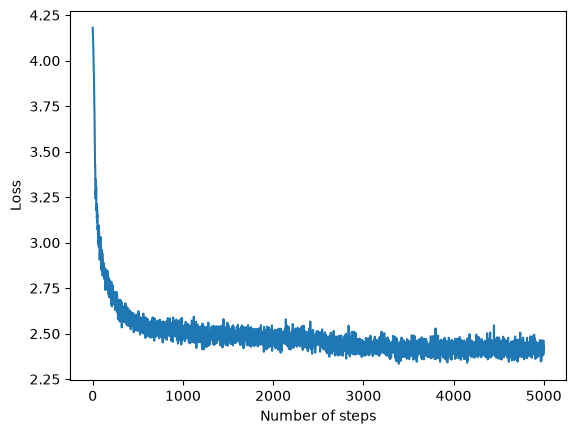

In [96]:
# Graph the results
plt.plot(np.linspace(0, total_steps-1, total_steps), losses)
plt.xlabel('Number of steps')
plt.ylabel('Loss')

In [97]:
# Autoregressive generation
tokens_to_gen = 200
random_char = unique_chars[random.randint(0, vocab_size-1)]
start_token = encode(random_char)[0]

generated_tokens = []
generated_tokens.append(start_token)

for _ in range(tokens_to_gen-1):
    logits = model(torch.tensor(generated_tokens).reshape(1, -1)) # (1, seq_len, vocab)
    logits = logits[0, -1, :] # (vocab,)
    probs = F.softmax(logits, dim=-1)
    token = torch.multinomial(probs, num_samples=1) # Sampling
    generated_tokens.append(token.item())
    
decode(generated_tokens)


"p. DUF I I noryor, BLI he gre, t bre hane\n\nYowitheimy mears filasthayourlkint ANRATaveflloonthe thasit fthag\nCO:\nAnd tecy h heru at wreretose ind'linin y;\nWsse, fe at I ttat Ror broe.\n\nIffit, swowimyo"

Notice, the loss decreased, but not as much as we might expect. Why? Currently,
if we shuffle the positions of all previous tokens, that wont affect attention.
So predicting the next token for "The cat sat on the" vs "On the cat sat the"
should return the exact same probabilities. But clearly the next token we should
predict should be different for both of these sequences (albeit this example
works better for a bigger tokenizer rather than character level)

The solution? Encode positions per token as well. We will add this in the next
notebook